In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import mod as m 

In [2]:
# USER INPUT: data information
date = '04-17-26'
path = f'Data/HighPressureTesting-{date}/'
p = 705

ps = [363, p]

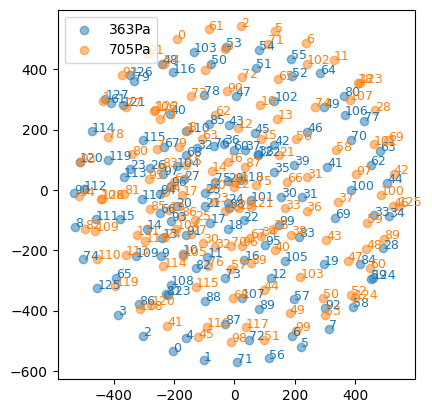

In [3]:
fig, ax = plt.subplots()

for i, p in enumerate( ps ): 
    arr = np.loadtxt(path+f"WithRing-{p}Pa.txt")
    ax.scatter(arr[:,0], arr[:,1], color=f'C{i}', alpha=0.5, label=f'{p}Pa')    
    for j, (xi, yi) in enumerate(zip(arr[:,0], arr[:,1])):
        ax.text(xi, yi, str(j), fontsize=9, color=f'C{i}')

ax.set_aspect('equal')
ax.legend()    

In [16]:
arr = np.loadtxt(path+f"WithRing-{p}Pa.txt")
ref = np.loadtxt(path+f"WithRing-363Pa.txt")

x, y, z = arr[:,1], arr[:,0], arr[:,2]

### OPTIONAL: Rotate by specified angle to align x,y 

In [17]:
theta = np.deg2rad(-90-12)

A = [[np.cos(theta), -np.sin(theta)], 
     [np.sin(theta), np.cos(theta)]]

arr = ( A @ np.vstack([x, y]) ).T  
arr.shape

(127, 2)

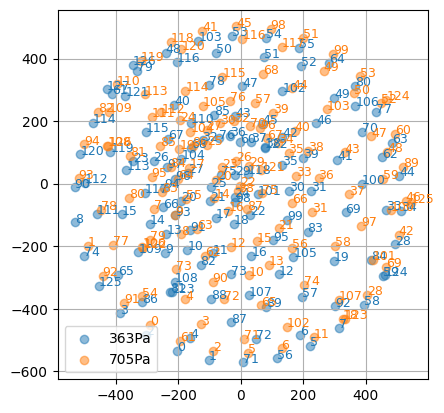

In [18]:
fig, ax = plt.subplots()
    
ax.scatter(ref[:,0], ref[:,1], color=f'C0', alpha=0.5, label=f'363Pa')    
for j, (xi, yi) in enumerate(zip(ref[:,0], ref[:,1])):
    ax.text(xi, yi, str(j), fontsize=9, color=f'C0')


ax.scatter(arr[:,0], arr[:,1], color=f'C1', alpha=0.5, label=f'{p}Pa')    
for j, (xi, yi) in enumerate(zip(arr[:,0], arr[:,1])):
    ax.text(xi, yi, str(j), fontsize=9, color=f'C1')


ax.grid()
ax.set_aspect('equal')
ax.legend()    

### Select at least three points for reference for the alignment

In [23]:

# From Blue points
ind_ref =[1, 55, 74] ## USER INPUT: select index of points 
ref_r = np.vstack([ref[ind_ref,0], ref[ind_ref,1]]).T

# From Orange points
ind_arr = [2, 51, 1] ## USER INPUT: select index of points 
arr_r = np.vstack([arr[ind_arr,0], arr[ind_arr,1]]).T 


### Rotaton 

In [24]:
rotate, R = m.align_points_2d(ref_r, arr_r)

arr_s = np.vstack([arr[:,0], arr[:,1]]).T

arr_new = (R @ arr_s.T).T
arr_new.shape

(127, 2)

### Translation

In [25]:

x, y = m.linear_transformation(ref, arr_new, ind_ref[0], ind_arr[0])

### Confirm result

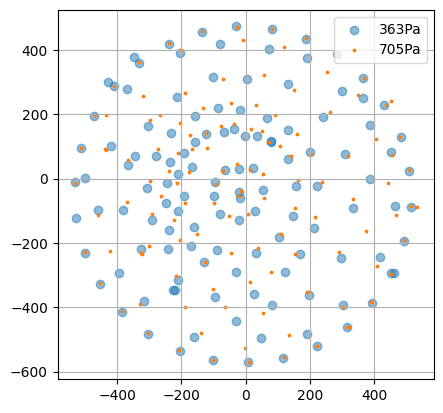

In [26]:
fig, ax = plt.subplots()

ax.scatter(ref[:,0], ref[:,1], color=f'C0', alpha=0.5, label=f'363Pa')
ax.scatter(x, y, color=f'C1', s=3, label=f'{p}Pa')    

ax.grid()
ax.set_aspect('equal')
ax.legend()    

### Save file

In [27]:
filename = f"{p}Pa.txt"
m.write_txt_from_arrays("WithRing-"+filename, x, y, z, date)